In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from sklearn.utils import resample

from torch.profiler import profile, record_function, ProfilerActivity


In [2]:
import os

balanced = True

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False


In [3]:
# Source - https://stackoverflow.com/a/51014127
# Posted by M. Deckers, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-03, License - CC BY-SA 4.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)

counts = df_tv['Irrigation_Need'].value_counts()

#balanced data set
df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# Downsample majority class
majority_downsampled = resample(df_tv_majority, 
                              replace=False,  # Sample without replacement
                              n_samples=len(df_tv_mid),  # Equalize class sizes
                              random_state=42)
# Oversample minority class
minority_upsampled = resample(df_tv_minority, 
                              replace=True,  # Sample with replacement
                              n_samples=len(df_tv_mid),  # Equalize class sizes
                              random_state=42)
# # Oversample mid class
# mid_upsampled = resample(df_tv_mid, 
#                          replace=True,  # Sample with replacement
#                          n_samples=len(df_tv_majority),  # Equalize class sizes
#                          random_state=42)
#df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
df_tv = df_balanced if balanced else df_tv

In [5]:
continous_variables = df_tv.select_dtypes(['float64']).columns
from sklearn.preprocessing import LabelEncoder
class_le = LabelEncoder()
y = class_le.fit_transform(df_tv['Irrigation_Need'].values)

In [6]:
df_dummy = pd.get_dummies(df_tv.iloc[:,1:-1], dtype=int)
from sklearn.preprocessing import StandardScaler

#df_dummy[continous_variables] = StandardScaler().fit_transform(df_dummy[continous_variables])

#x = df_dummy.to_numpy()

sc = StandardScaler().fit(df_dummy[continous_variables])
df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
x = df_dummy.to_numpy()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(x, y, 
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [8]:
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_train.to(device)
y_train.to(device)
train_ds = TensorDataset(X_train, y_train)

batch_size = 256
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [25]:
hidden_units = [64,32, 16]
input_size = X_train.shape[1]


all_layers = nn.ModuleList()
#all_layers.append(nn.Flatten())
#all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], len(class_le.classes_)))   
#all_layers.append(nn.Softmax(dim=3))
model = nn.Sequential(*all_layers)
model.to(device)

Sequential(
  (0): Linear(in_features=43, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=3, bias=True)
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.to(device))
        loss = loss_fn(pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch.to(device)).float()
        accuracy_hist_train += is_correct.sum().cpu()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

KeyboardInterrupt: 

/tmp/ipykernel_167019/1265932843.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test).float()


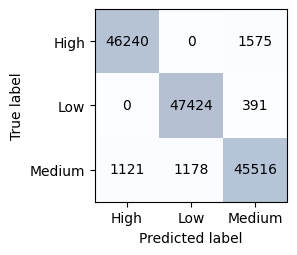

In [17]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

model.to('cpu')
X_test = torch.tensor(X_test).float()
with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)

labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [11]:
if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

torch.save(model, os.path.join(out_dir, 'model_nn_v2.pt'))

In [78]:
# pred = model(X_test)
# is_correct = (torch.argmax(pred, dim=1) == y_test).float()
# print(f'Test accuracy: {is_correct.mean():.4f}') 

In [16]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values


df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], dtype=int)
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = torch.tensor(df_test_dummy.to_numpy()).float()
#x_test.to(device)

In [18]:
model.to('cpu')
with torch.no_grad():   
    df_submission_nn = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(torch.argmax(model(x_test), dim=1))})
    df_submission_nn.to_csv(os.path.join(out_dir, 'submission-nn_v2.csv'), index=False)